<a href="https://colab.research.google.com/github/ewiw24/cvd-risk-classification-shap/blob/main/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Libraries loaded
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape     : (70000, 13)
Columns   : ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years']

Data Types:
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
age_years      float64
dtype: object
── Missing Values ──
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64

── Target Distribution ──
cardio
0    35021
1    34979
Name: count, dtype: int64
cardio
0    50.03
1    4

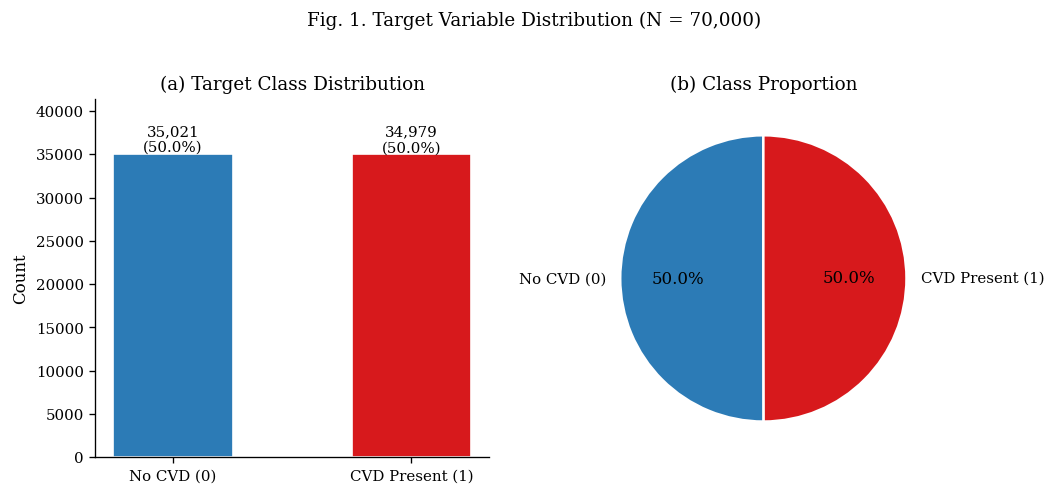

── Age Distribution Summary ──
Min    : 29.6 yrs
Max    : 64.9 yrs
Mean   : 53.3 yrs
Median : 53.9 yrs

── WHO Group Counts ──
age_who
Young Adult (18–39)        4
Middle-Aged (40–54)    35434
Older Adult (55+)      34562
Name: count, dtype: int64


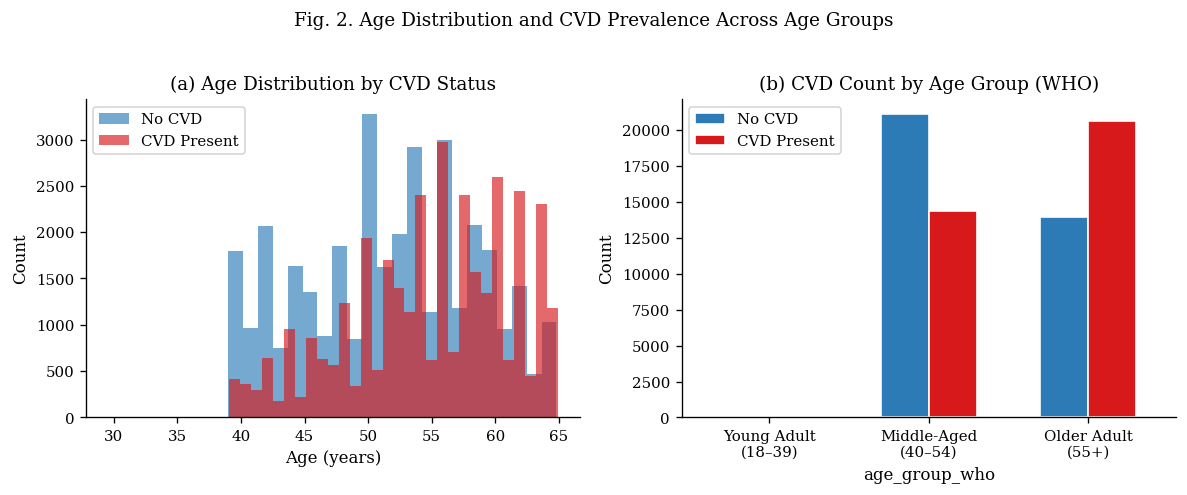

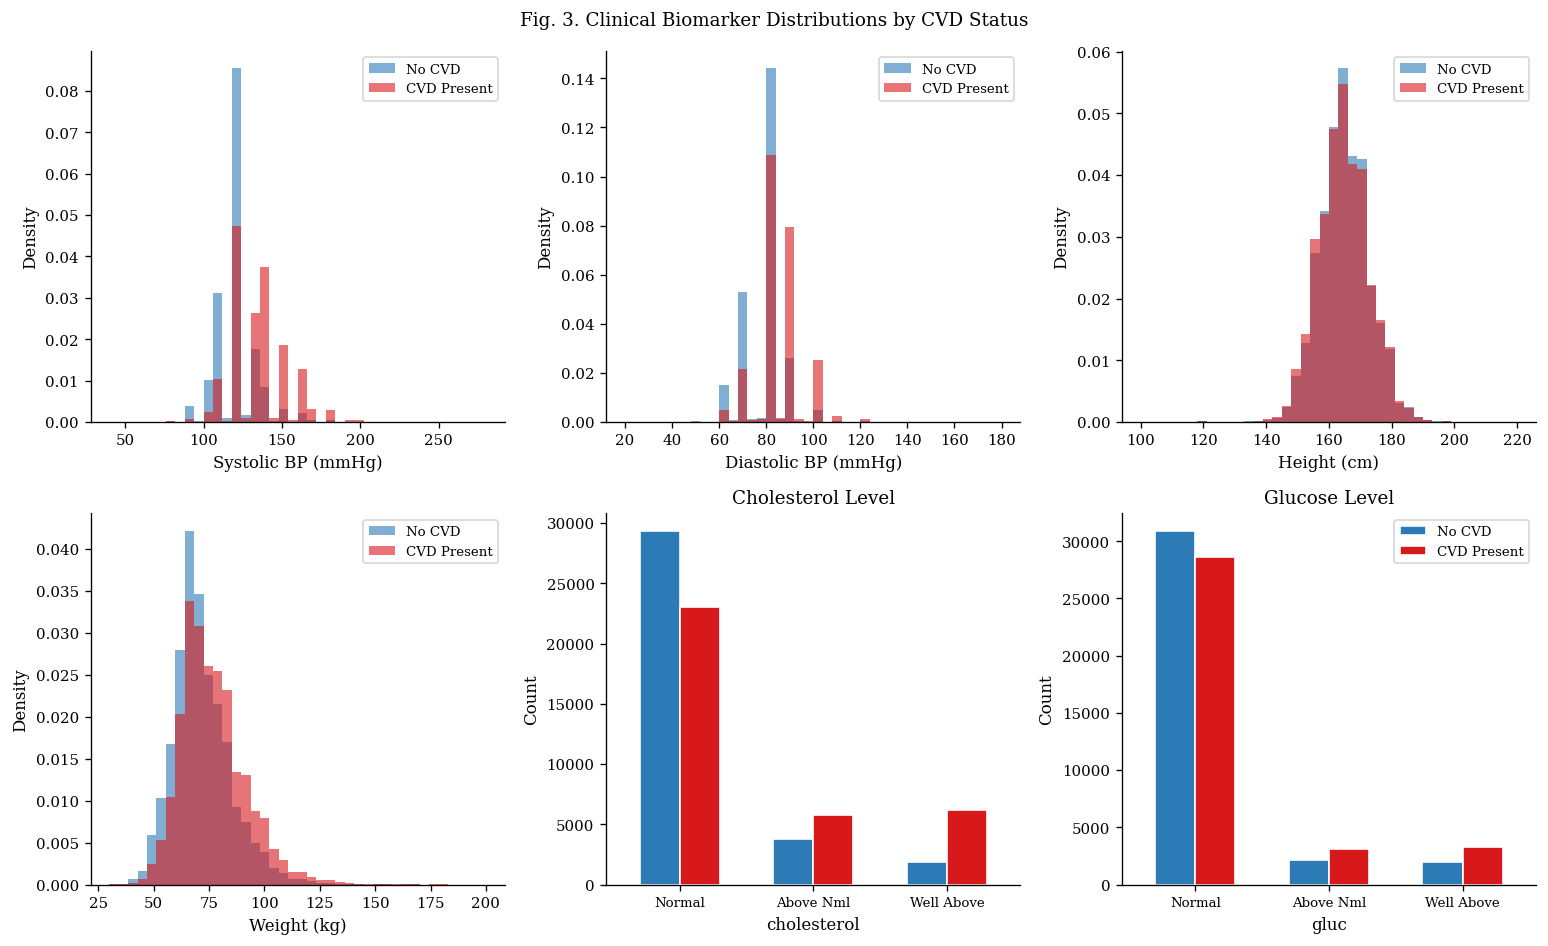

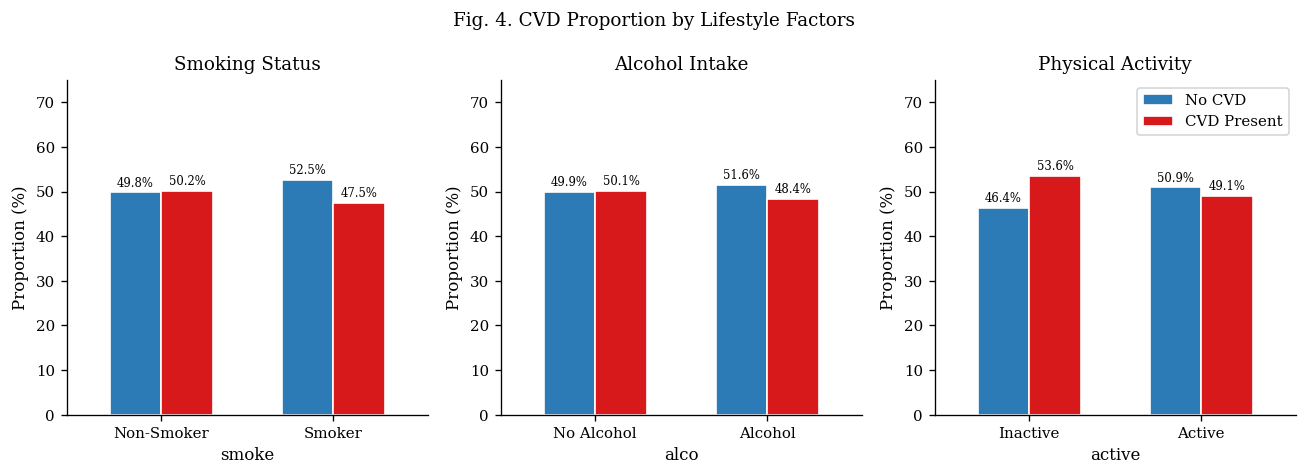

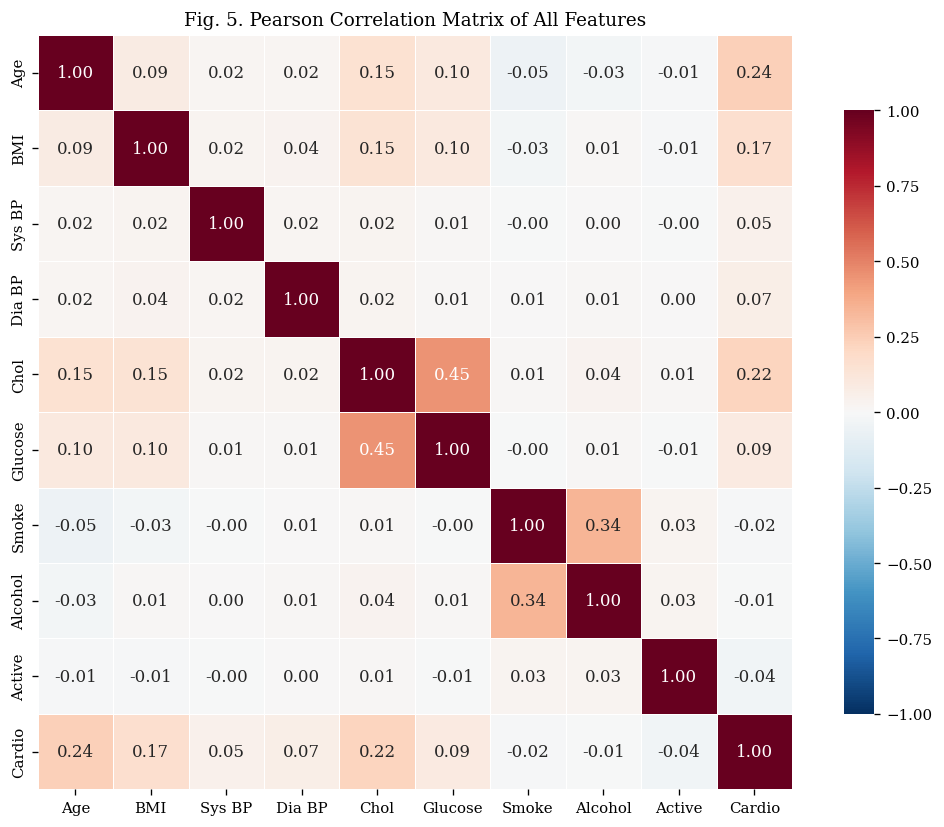

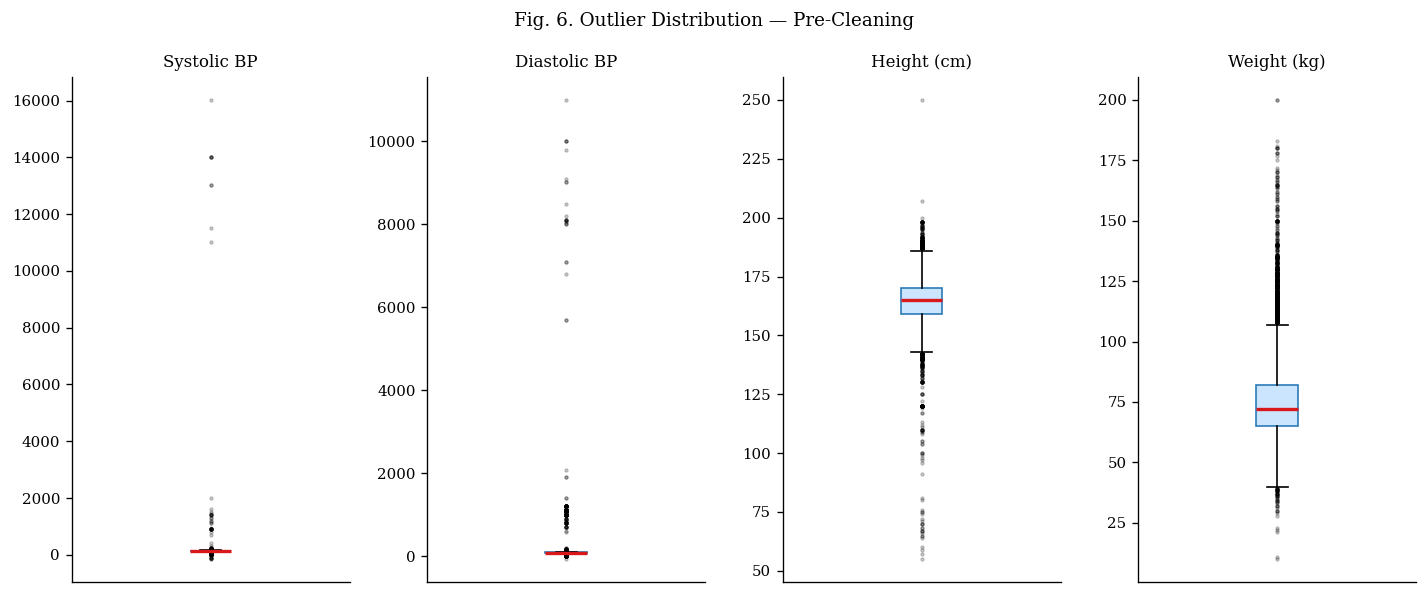


✅ EDA complete — 6 figures saved to Drive
📌 Key findings:
   - No missing values
   - Class balance: 50.03% / 49.97% — no resampling needed
   - Age range: 29.6–64.9 yrs
   - Extreme outliers present in ap_hi, ap_lo → remove in preprocessing
   - Systolic BP shows highest correlation with target


In [3]:
# ── MARKDOWN ──────────────────────────────────────────────────
# # 01 — Exploratory Data Analysis
# **Project:** CVD Risk Classification with Explainable AI
# **Dataset:** Cardiovascular Disease Dataset (Sulianova, Kaggle 2019)
# **Goal:** Understand data structure, distributions, class balance,
# and outliers before preprocessing.

# ── CELL 1: Install & Imports ──────────────────────────────────
!pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 10,
    'axes.titlesize'   : 11,
    'axes.labelsize'   : 10,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'legend.fontsize'  : 9,
    'figure.dpi'       : 120,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
PALETTE = ['#2c7bb6', '#d7191c']
print("✅ Libraries loaded")

# ── CELL 2: Load Data ─────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/CVD_Project'
df = pd.read_csv(f'{SAVE_DIR}/cardio_train.csv', sep=';')
df.drop(columns=['id'], inplace=True)
df['age_years'] = df['age'] / 365.25

print(f"Shape     : {df.shape}")
print(f"Columns   : {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 1. Basic Overview

# ── CELL 3: Overview Stats ────────────────────────────────────
print("── Missing Values ──")
print(df.isnull().sum())

print("\n── Target Distribution ──")
print(df['cardio'].value_counts())
print(df['cardio'].value_counts(normalize=True).mul(100).round(2))

print("\n── Descriptive Statistics ──")
df[['age_years','height','weight','ap_hi','ap_lo']].describe().round(2)

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 2. Class Distribution
# Near-perfect 50/50 balance — no resampling needed.

# ── CELL 4: Fig 1 — Class Distribution ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
counts = df['cardio'].value_counts().sort_index()
labels = ['No CVD (0)', 'CVD Present (1)']

axes[0].bar(labels, counts.values, color=PALETTE,
            edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300,
                 f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=9)
axes[0].set_title('(a) Target Class Distribution')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(counts.values) * 1.18)

axes[1].pie(counts.values, labels=labels, colors=PALETTE,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('(b) Class Proportion')

plt.suptitle('Fig. 1. Target Variable Distribution (N = 70,000)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig1_class_distribution.png')
plt.show()

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 3. Age Distribution
# Dataset is concentrated in 39–65 years.
# Young Adult (18–39) is severely underrepresented (<0.1%).
# This informs our decision to use tercile-based age grouping
# rather than standard WHO categories.

# ── CELL 5: Fig 2 — Age Distribution ─────────────────────────
print("── Age Distribution Summary ──")
print(f"Min    : {df['age_years'].min():.1f} yrs")
print(f"Max    : {df['age_years'].max():.1f} yrs")
print(f"Mean   : {df['age_years'].mean():.1f} yrs")
print(f"Median : {df['age_years'].median():.1f} yrs")

# WHO groups for reference
bins_who = [0, 39, 54, 120]
labels_who = ['Young Adult (18–39)', 'Middle-Aged (40–54)', 'Older Adult (55+)']
df['age_who'] = pd.cut(df['age_years'], bins=bins_who, labels=labels_who)
print(f"\n── WHO Group Counts ──")
print(df['age_who'].value_counts().sort_index())

# ── CELL 6: Age Distribution Plot ────────────────────────────
bins_plot = [0, 39, 54, 120]
labels_age = ['Young Adult\n(18–39)', 'Middle-Aged\n(40–54)', 'Older Adult\n(55+)']
df['age_group_who'] = pd.cut(df['age_years'], bins=bins_plot, labels=labels_age)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, (label, color) in enumerate(zip(['No CVD', 'CVD Present'], PALETTE)):
    axes[0].hist(df[df['cardio'] == i]['age_years'],
                 bins=30, alpha=0.65, color=color,
                 label=label, edgecolor='none')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].set_title('(a) Age Distribution by CVD Status')
axes[0].legend()

age_cvd = (df.groupby(['age_group_who', 'cardio'], observed=True)
             .size().unstack())
age_cvd.plot(kind='bar', color=PALETTE, ax=axes[1],
             edgecolor='white', width=0.6)
axes[1].set_title('(b) CVD Count by Age Group (WHO)')
axes[1].set_xticklabels(labels_age, rotation=0, fontsize=9)
axes[1].set_ylabel('Count')
axes[1].legend(['No CVD', 'CVD Present'])

plt.suptitle('Fig. 2. Age Distribution and CVD Prevalence Across Age Groups',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig2_age_distribution.png')
plt.show()

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 4. Clinical Biomarker Distributions

# ── CELL 7: Fig 3 — Clinical Distributions ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

clinical_vars = [
    ('ap_hi',  'Systolic BP (mmHg)',  (40,  280)),
    ('ap_lo',  'Diastolic BP (mmHg)', (20,  180)),
    ('height', 'Height (cm)',         (100, 220)),
    ('weight', 'Weight (kg)',         (30,  200)),
]
for ax, (col, xlabel, xlim) in zip(axes.flat[:4], clinical_vars):
    for i, (label, color) in enumerate(zip(['No CVD', 'CVD Present'], PALETTE)):
        ax.hist(df[df['cardio'] == i][col], bins=40, alpha=0.6,
                color=color, label=label, range=xlim,
                edgecolor='none', density=True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

chol_cvd = df.groupby(['cholesterol', 'cardio']).size().unstack()
chol_cvd.plot(kind='bar', color=PALETTE, ax=axes[1,1],
              edgecolor='white', width=0.6, legend=False)
axes[1,1].set_title('Cholesterol Level')
axes[1,1].set_xticklabels(['Normal','Above Nml','Well Above'],
                           rotation=0, fontsize=8)
axes[1,1].set_ylabel('Count')

gluc_cvd = df.groupby(['gluc', 'cardio']).size().unstack()
gluc_cvd.plot(kind='bar', color=PALETTE, ax=axes[1,2],
              edgecolor='white', width=0.6)
axes[1,2].set_title('Glucose Level')
axes[1,2].set_xticklabels(['Normal','Above Nml','Well Above'],
                           rotation=0, fontsize=8)
axes[1,2].set_ylabel('Count')
axes[1,2].legend(['No CVD', 'CVD Present'], fontsize=8)

plt.suptitle('Fig. 3. Clinical Biomarker Distributions by CVD Status',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig3_clinical_distributions.png')
plt.show()

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 5. Lifestyle Variable Analysis

# ── CELL 8: Fig 4 — Lifestyle Variables ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
lifestyle_vars = [
    ('smoke',  'Smoking Status',    ['Non-Smoker', 'Smoker']),
    ('alco',   'Alcohol Intake',    ['No Alcohol', 'Alcohol']),
    ('active', 'Physical Activity', ['Inactive',   'Active']),
]
for ax, (col, title, xlabels) in zip(axes, lifestyle_vars):
    cvd_pct = (df.groupby([col, 'cardio'])
                 .size().unstack()
                 .div(df.groupby(col).size(), axis=0) * 100)
    cvd_pct.plot(kind='bar', color=PALETTE, ax=ax,
                 edgecolor='white', width=0.6, legend=False)
    ax.set_title(title)
    ax.set_xticklabels(xlabels, rotation=0, fontsize=9)
    ax.set_ylabel('Proportion (%)')
    ax.set_ylim(0, 75)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=7, padding=2)

axes[2].legend(['No CVD', 'CVD Present'], loc='upper right')
plt.suptitle('Fig. 4. CVD Proportion by Lifestyle Factors', fontsize=11)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig4_lifestyle_variables.png')
plt.show()

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 6. Correlation Heatmap

# ── CELL 9: Fig 5 — Correlation Heatmap ──────────────────────
df['bmi'] = df['weight'] / (df['height'] / 100) ** 2

num_cols = ['age_years', 'bmi', 'ap_hi', 'ap_lo',
            'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8},
            xticklabels=['Age','BMI','Sys BP','Dia BP','Chol',
                         'Glucose','Smoke','Alcohol','Active','Cardio'],
            yticklabels=['Age','BMI','Sys BP','Dia BP','Chol',
                         'Glucose','Smoke','Alcohol','Active','Cardio'])
ax.set_title('Fig. 5. Pearson Correlation Matrix of All Features',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig5_correlation_heatmap.png')
plt.show()

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 7. Outlier Detection
# Extreme values in ap_hi (max = 16,020 mmHg) and ap_lo
# are clearly recording artifacts — will be removed in preprocessing.

# ── CELL 10: Fig 6 — Outlier Boxplots ────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(12, 5))
vars_bp = [('ap_hi','Systolic BP'), ('ap_lo','Diastolic BP'),
           ('height','Height (cm)'), ('weight','Weight (kg)')]

for ax, (col, title) in zip(axes, vars_bp):
    ax.boxplot(df[col], patch_artist=True,
               boxprops    =dict(facecolor='#cce5ff', color='#2c7bb6'),
               medianprops =dict(color='#d7191c', linewidth=2),
               flierprops  =dict(marker='.', color='gray',
                                 alpha=0.3, markersize=3))
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])

plt.suptitle('Fig. 6. Outlier Distribution — Pre-Cleaning', fontsize=11)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig6_outlier_boxplots.png')
plt.show()

print("\n✅ EDA complete — 6 figures saved to Drive")
print("📌 Key findings:")
print("   - No missing values")
print("   - Class balance: 50.03% / 49.97% — no resampling needed")
print(f"   - Age range: {df['age_years'].min():.1f}–{df['age_years'].max():.1f} yrs")
print("   - Extreme outliers present in ap_hi, ap_lo → remove in preprocessing")
print("   - Systolic BP shows highest correlation with target")